# 🔐 Practical: Museum Night Shift (MDPs & Dynamic Programming)

**Goal (1 hour):** Turn a real-world story into an MDP, then solve it with **Value Iteration** and **Policy Iteration**, and visualize the resulting policy/value.

This notebook includes **auto-grading** cells.  
- Run all cells top-to-bottom.
- At the end, run **`run_autograder()`** to get your score.


## 1) Story → MDP (Warm-up)

A security robot patrols a museum at night.

- Start: **S**
- Goal: **G** (terminal, reward +1)
- Trap: **T** (terminal, reward −1)
- Walls: **#**
- Empty cells: **.**
- Each step costs time/energy: reward **−0.04**
- Actions are **stochastic**: intended action succeeds with probability **1−ε**, otherwise it *slips* left/right.

**Your task:** implement the missing pieces of the MDP and the DP algorithms.

### Grid (6×6)
```
S . . # . .
. # . # . .
. # . . . .
. . # # . T
# . . . # .
. . # . . G
```


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random

np.set_printoptions(precision=3, suppress=True)

GRID = [
    "S..#..",
    ".#.#..",
    ".#....",
    "..##.T",
    "#...#.",
    "..#..G"
]

N_ROWS = len(GRID)
N_COLS = len(GRID[0])

ACTIONS = ["UP", "RIGHT", "DOWN", "LEFT"]
ACTION_TO_DELTA = {
    "UP": (-1, 0),
    "RIGHT": (0, 1),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
}
LEFT_OF = {"UP": "LEFT", "LEFT": "DOWN", "DOWN": "RIGHT", "RIGHT": "UP"}
RIGHT_OF = {"UP": "RIGHT", "RIGHT": "DOWN", "DOWN": "LEFT", "LEFT": "UP"}

STEP_COST = -0.04
GAMMA = 0.99
EPSILON = 0.2


def is_terminal(r, c):
    return GRID[r][c] in ("G", "T")


def terminal_reward(r, c):
    if GRID[r][c] == "G":
        return 1.0
    if GRID[r][c] == "T":
        return -1.0
    return 0.0


In [17]:
# TODO 1: Enumerate all non-wall states and build index mappings.
# Return:
#   state_to_idx: dict mapping (r,c)->int
#   idx_to_state: list mapping int->(r,c)

def enumerate_states(grid):
    state_to_idx = {}
    idx_to_state = []
    for r in range(N_ROWS):
        for c in range(N_COLS):
            if grid[r][c] != "#":
                idx = len(idx_to_state)
                state_to_idx[(r, c)] = idx
                idx_to_state.append((r, c))
    return state_to_idx, idx_to_state


state_to_idx, idx_to_state = enumerate_states(GRID)
N_STATES = len(idx_to_state)
N_ACTIONS = len(ACTIONS)
print("Number of states:", N_STATES)


Number of states: 27


In [18]:
# TODO 2: Deterministic step: move one cell unless boundary/wall, in which case stay.

def deterministic_step(state, action):
    r, c = state
    dr, dc = ACTION_TO_DELTA[action]
    nr, nc = r + dr, c + dc
    if nr < 0 or nr >= N_ROWS or nc < 0 or nc >= N_COLS:
        return (r, c)
    if GRID[nr][nc] == "#":
        return (r, c)
    return (nr, nc)


In [19]:
# TODO 3: Stochastic transitions with slip probability eps.
# With prob 1-eps: intended action
# With prob eps/2: slip to LEFT_OF[action]
# With prob eps/2: slip to RIGHT_OF[action]
# If state is terminal: return [(1.0, state)]

def transition_probs(state, action, eps=EPSILON):
    if is_terminal(*state):
        return [(1.0, state)]
    outcomes = []
    for prob, act in [
        (1 - eps, action),
        (eps / 2, LEFT_OF[action]),
        (eps / 2, RIGHT_OF[action]),
    ]:
        outcomes.append((prob, deterministic_step(state, act)))
    return outcomes


In [20]:
# TODO 4: Reward function.
# If next_state is terminal: terminal_reward(next_state)
# Else: STEP_COST

def reward(state, action, next_state):
    r, c = next_state
    if is_terminal(r, c):
        return terminal_reward(r, c)
    return STEP_COST


In [22]:
# Build MDP transitions P[s][a] = list of (p, s_next, r)

P = defaultdict(lambda: defaultdict(list))

for s_idx, s in enumerate(idx_to_state):
    for a_idx, a in enumerate(ACTIONS):
        for p, s_next in transition_probs(s, a):
            r = reward(s, a, s_next)
            s_next_idx = state_to_idx[s_next]
            P[s_idx][a_idx].append((p, s_next_idx, r))

print("Built transitions for", N_STATES, "states.")


Built transitions for 27 states.


In [ ]:
# TODO 5: Value Iteration
# Implement Bellman optimality backup:

$$
Q(s,a) = \sum_{(p, s', r) \in \mathcal{P}(s,a)} p \left( r + \gamma V(s') \right)
$$

$$
V(s) = \max_a Q(s,a)
$$

In [23]:
def value_iteration(P, gamma=GAMMA, theta=1e-6, max_iters=100000):
    V = np.zeros(N_STATES)
    it = 0
    while True:
        it += 1
        delta = 0.0
        for s in range(N_STATES):
            v_old = V[s]
            q_vals = []
            for a in range(N_ACTIONS):
                q = 0
                for p, s_next, r in P[s][a]:
                    q += p * (r + gamma * V[s_next])
                q_vals.append(q)
            V[s] = max(q_vals)
            delta = max(delta, abs(v_old - V[s]))
        if delta < theta or it >= max_iters:
            break
    return V, it


In [24]:
# TODO 6: Greedy policy extraction from a value function.

def extract_greedy_policy(V, gamma=GAMMA):
    pi = np.zeros(N_STATES, dtype=int)
    for s in range(N_STATES):
        q_vals = []
        for a in range(N_ACTIONS):
            q = 0
            for p, s_next, r in P[s][a]:
                q += p * (r + gamma * V[s_next])
            q_vals.append(q)
        pi[s] = int(np.argmax(q_vals))
    return pi


In [25]:
V_star, vi_iters = value_iteration(P)
pi_star = extract_greedy_policy(V_star)
print("VI iters:", vi_iters)


VI iters: 1376


In [ ]:
# TODO 7: Policy evaluation (iterative):

$$
V(s) \leftarrow 
\sum_{(p, s', r) \in \mathcal{P}(s, \pi(s))} 
p \left( r + \gamma V(s') \right)
$$

In [26]:
def policy_evaluation(pi, P, gamma=GAMMA, theta=1e-6, max_sweeps=100000):
    V = np.zeros(N_STATES)
    sweeps = 0
    while True:
        sweeps += 1
        delta = 0.0
        for s in range(N_STATES):
            v_old = V[s]
            a = pi[s]
            v_new = 0.0
            for p, s_next, r in P[s][a]:
                v_new += p * (r + gamma * V[s_next])
            V[s] = v_new
            delta = max(delta, abs(v_old - V[s]))
        if delta < theta or sweeps >= max_sweeps:
            break
    return V, sweeps


In [27]:
# TODO 8: Policy Iteration: evaluation + greedy improvement until stable.

def policy_iteration(P, gamma=GAMMA, theta_eval=1e-6):
    pi = np.random.randint(N_ACTIONS, size=N_STATES)
    outer = 0
    total_sweeps = 0
    while True:
        outer += 1
        V, sweeps = policy_evaluation(pi, P, gamma=gamma, theta=theta_eval)
        total_sweeps += sweeps

        stable = True
        for s in range(N_STATES):
            old = pi[s]
            q_vals = []
            for a in range(N_ACTIONS):
                q = 0.0
                for p, s_next, r in P[s][a]:
                    q += p * (r + gamma * V[s_next])
                q_vals.append(q)
            pi[s] = int(np.argmax(q_vals))
            if pi[s] != old:
                stable = False

        if stable:
            break
    return pi, V, outer, total_sweeps


In [28]:
pi_pi, V_pi, pi_outer, pi_sweeps = policy_iteration(P)
print("PI outer iters:", pi_outer, "policy-eval sweeps:", pi_sweeps)


PI outer iters: 5 policy-eval sweeps: 6880


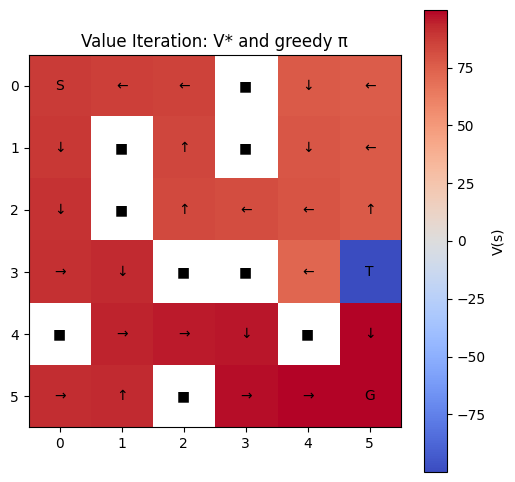

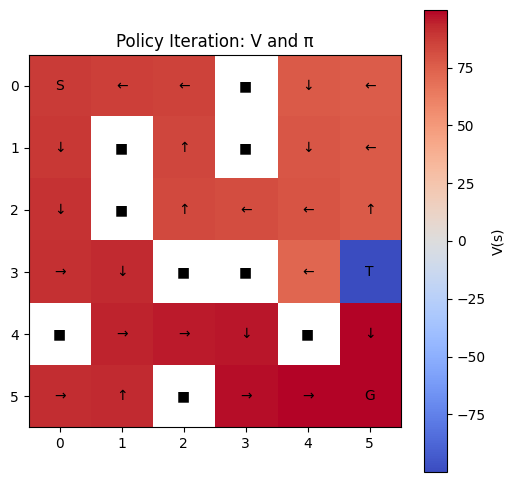

In [29]:
ARROWS = ["↑", "→", "↓", "←"]


def plot_policy_and_values(V, pi, title="Policy and Value"):
    grid_V = np.full((N_ROWS, N_COLS), np.nan)
    grid_pi = np.full((N_ROWS, N_COLS), "", dtype=object)
    for idx, (r, c) in enumerate(idx_to_state):
        grid_V[r, c] = V[idx]
        grid_pi[r, c] = ARROWS[pi[idx]]

    plt.figure(figsize=(6, 6))
    plt.imshow(grid_V, cmap="coolwarm")
    plt.colorbar(label="V(s)")
    for r in range(N_ROWS):
        for c in range(N_COLS):
            if GRID[r][c] == "#":
                plt.text(c, r, "■", ha="center", va="center", color="black")
            elif GRID[r][c] in ("G", "T", "S"):
                plt.text(c, r, GRID[r][c], ha="center", va="center", color="black")
            else:
                plt.text(c, r, grid_pi[r, c], ha="center", va="center", color="black")
    plt.title(title)
    plt.show()


plot_policy_and_values(V_star, pi_star, title="Value Iteration: V* and greedy π")
plot_policy_and_values(V_pi, pi_pi, title="Policy Iteration: V and π")


In [30]:
def simulate(start_state, pi, max_steps=200, eps=EPSILON):
    s = start_state
    total = 0.0
    steps = 0
    for _ in range(max_steps):
        steps += 1
        if is_terminal(*s):
            break
        s_idx = state_to_idx[s]
        a = ACTIONS[pi[s_idx]]
        transitions = transition_probs(s, a, eps=eps)
        probs, next_states = zip(*transitions)
        s_next = random.choices(next_states, probs)[0]
        total += reward(s, a, s_next)
        s = s_next
    return total, s, steps


def find_start():
    for r in range(N_ROWS):
        for c in range(N_COLS):
            if GRID[r][c] == "S":
                return (r, c)
    raise RuntimeError("No start state S found")


start = find_start()

# Run multiple rollouts under greedy policy from VI
R = []
ends = {"G": 0, "T": 0, "other": 0}
for _ in range(50):
    ret, end_state, steps = simulate(start, pi_star)
    R.append(ret)
    ch = GRID[end_state[0]][end_state[1]]
    if ch == "G":
        ends["G"] += 1
    elif ch == "T":
        ends["T"] += 1
    else:
        ends["other"] += 1

print("Rollouts (50) under VI greedy policy:")
print("  reach G:", ends["G"], "reach T:", ends["T"], "other:", ends["other"])
print("  avg return:", float(np.mean(R)), "avg steps:",
      float(np.mean([simulate(start, pi_star)[2] for _ in range(20)])))


Rollouts (50) under VI greedy policy:
  reach G: 50 reach T: 0 other: 0
  avg return: 0.472 avg steps: 15.05


### Tiny theory check (1 minute)

Fill in the blank:

Show that the Bellman expectation operator $T^\pi$ is a contraction:

$$
\|T^\pi V - T^\pi W\|_\infty
= \max_s \left| \sum_{s'} P(s' \mid s, \pi(s)) \, \gamma \big( V(s') - W(s') \big) \right|
\le \underline{\hspace{2cm}} \cdot \|V - W\|_\infty$$



In [31]:
# =========================
# Auto-grader (run at end)
# =========================

def _assert_close(x, y, tol=1e-6, msg=""):
    if abs(x - y) > tol:
        raise AssertionError(msg or f"Expected {y}, got {x} (tol={tol})")


def _check(cond, msg):
    if not cond:
        raise AssertionError(msg)


def _cell_score(points, fn):
    try:
        fn()
        return points, None
    except Exception as e:
        return 0, str(e)


def run_autograder(verbose=True):
    tests = []

    # Test 1: state enumeration basics
    def t1():
        _check(isinstance(state_to_idx, dict), "state_to_idx must be a dict")
        _check(isinstance(idx_to_state, list), "idx_to_state must be a list")
        _check(len(idx_to_state) == len(state_to_idx), "Mappings must have same size")
        # Expected number of non-wall cells for the fixed grid:
        # Total cells 36, walls count:
        walls = sum(row.count("#") for row in GRID)
        _check(len(idx_to_state) == 36 - walls, "Incorrect number of states")
        # start exists
        _check(any(GRID[r][c] == "S" for (r, c) in idx_to_state), "Start state S missing")

    tests.append(("State enumeration", 10, t1))

    # Test 2: deterministic step handles walls/boundaries
    def t2():
        # from (0,0) UP should stay
        _check(deterministic_step((0, 0), "UP") == (0, 0), "Boundary handling failed")
        # move into wall should stay: from (0,2) RIGHT hits # at (0,3)
        _check(deterministic_step((0, 2), "RIGHT") == (0, 2), "Wall handling failed")

    tests.append(("Deterministic step", 10, t2))

    # Test 3: transition probs sum to 1 and terminal absorbing
    def t3():
        s = (0, 0)
        outs = transition_probs(s, "RIGHT", eps=0.2)
        ps = sum(p for p, _ in outs)
        _assert_close(ps, 1.0, tol=1e-9, msg="Transition probabilities must sum to 1")
        # terminal absorbing
        # find a terminal
        term = None
        for (r, c) in idx_to_state:
            if GRID[r][c] in ("G", "T"):
                term = (r, c);
                break
        outs2 = transition_probs(term, "UP", eps=0.2)
        _check(len(outs2) == 1 and outs2[0][0] == 1.0 and outs2[0][1] == term, "Terminal state must be absorbing")

    tests.append(("Transition model", 15, t3))

    # Test 4: reward function
    def t4():
        # step cost on non-terminal transition
        r = reward((0, 0), "RIGHT", deterministic_step((0, 0), "RIGHT"))
        _assert_close(r, STEP_COST, tol=1e-9, msg="Non-terminal step reward must be STEP_COST")
        # terminal reward when entering terminal
        # find neighbor that can enter goal if possible, else directly test terminal cell reward by next_state
        goal = None
        for (rr, cc) in idx_to_state:
            if GRID[rr][cc] == "G":
                goal = (rr, cc)
        _check(goal is not None, "Goal not found")
        _assert_close(reward((0, 0), "UP", goal), 1.0, tol=1e-9, msg="Entering G must give +1")

    tests.append(("Reward function", 10, t4))

    # Test 5: Value iteration produces sensible values (monotonicity-ish + terminal ordering)
    def t5():
        V, iters = value_iteration(P, gamma=GAMMA, theta=1e-6, max_iters=20000)
        _check(np.isfinite(V).all(), "V contains non-finite values")
        _check(iters < 20000, "VI did not converge (max_iters hit)")
        # goal value should be >= trap value (since +1 vs -1 terminals)
        goal_idx = None;
        trap_idx = None
        for i, (r, c) in enumerate(idx_to_state):
            if GRID[r][c] == "G": goal_idx = i
            if GRID[r][c] == "T": trap_idx = i
        _check(goal_idx is not None and trap_idx is not None, "Missing terminal indices")
        _check(V[goal_idx] >= V[trap_idx], "Goal value should be >= trap value")

    tests.append(("Value Iteration", 25, t5))

    # Test 6: Greedy policy extraction returns valid actions
    def t6():
        V, _ = value_iteration(P, gamma=GAMMA, theta=1e-6, max_iters=20000)
        pi = extract_greedy_policy(V, gamma=GAMMA)
        _check(pi.shape == (N_STATES,), "Policy has wrong shape")
        _check(((0 <= pi) & (pi < N_ACTIONS)).all(), "Policy contains invalid actions")

    tests.append(("Greedy policy", 10, t6))

    # Test 7: Policy iteration runs and returns valid outputs
    def t7():
        pi, V, outer, sweeps = policy_iteration(P, gamma=GAMMA, theta_eval=1e-6)
        _check(((0 <= pi) & (pi < N_ACTIONS)).all(), "PI policy has invalid actions")
        _check(np.isfinite(V).all(), "PI V contains non-finite values")
        _check(outer >= 1 and sweeps >= 1, "PI iterations/sweeps look wrong")

    tests.append(("Policy Iteration", 20, t7))

    total = 0
    total_possible = sum(p for _, p, _ in tests)
    details = []
    for name, pts, fn in tests:
        sc, err = _cell_score(pts, fn)
        total += sc
        if verbose:
            if err is None:
                details.append(f"[OK] {name}: +{sc}/{pts}")
            else:
                details.append(f"[FAIL] {name}: +{sc}/{pts} — {err}")

    if verbose:
        print("\n".join(details))
        print(f"\nTOTAL: {total}/{total_possible}")

    return total, total_possible, details


In [32]:
run_autograder()

[OK] State enumeration: +10/10
[OK] Deterministic step: +10/10
[OK] Transition model: +15/15
[OK] Reward function: +10/10
[OK] Value Iteration: +25/25
[OK] Greedy policy: +10/10
[OK] Policy Iteration: +20/20

TOTAL: 100/100


(100,
 100,
 ['[OK] State enumeration: +10/10',
  '[OK] Deterministic step: +10/10',
  '[OK] Transition model: +15/15',
  '[OK] Reward function: +10/10',
  '[OK] Value Iteration: +25/25',
  '[OK] Greedy policy: +10/10',
  '[OK] Policy Iteration: +20/20'])

## Additional questions

1. How many iterations does **Value Iteration** take to converge, and how many outer iterations does **Policy Iteration** take?  
   Why does **Policy Iteration** typically converge in fewer iterations?

2. Why does the policy sometimes choose actions that hit a wall (i.e., result in no movement)?  
   Is this behavior a bug or a consequence of the MDP modeling?

4. How does changing the discount factor $\gamma$ (e.g., $\gamma = 0.8$ vs $\gamma = 0.99$) affect the agent’s behavior near the trap?

5. How does increasing the stochasticity parameter $\varepsilon$ change the structure of the optimal policy?

6. Which assumption is crucial for the contraction property of the Bellman operator?